## Milestone 1.1

In [1]:
!nvidia-smi

Fri Apr 21 01:54:50 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   47C    P8     9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [2]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

Your runtime has 13.6 gigabytes of available RAM



In [3]:
import requests
import pickle
import zipfile
import time
import os
#from google.colab import drive
import random
import glob
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import asarray
from PIL.ImageStat import Stat
!pip install pydicom
import pydicom
# Package for converting PNG Files to DICOM(.dcm ) format
!pip install simpleitk
import SimpleITK as sitk
from sklearn.model_selection import train_test_split
from PIL import Image
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import DataFrameIterator
#from keras_preprocessing.image.dataframe_iterator import DataFrameIterator
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense, Activation, MaxPool2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.applications import EfficientNetB0
#tf.keras.applications.efficientnet.EfficientNetB4
#tf.keras.applications.efficientnet.preprocess_input (not required for efficientnets)


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 69.4 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 MB 17.3 MB/s eta 0:00:00


In [4]:
data_path = './content'
archive_path = data_path + '/data/'
if os.path.exists(archive_path):
  print(f"{archive_path} directory exists.")
else:
  print(f"Did not find {archive_path} directory, creating one...")
  os.mkdir('./content')

  os.mkdir(archive_path)
  if os.path.exists(archive_path):
    print(f'{archive_path} created successfully')



Did not find ./content/data/ directory, creating one...
./content/data/ created successfully


In [5]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [6]:
!mv /content/gdrive/MyDrive/Manning_Projects/archive\ \(2\).zip /content/gdrive/MyDrive/Manning_Projects/covid_data.zip
!ls /content/gdrive/MyDrive/Manning_Projects/

mv: cannot stat '/content/gdrive/MyDrive/Manning_Projects/archive (2).zip': No such file or directory
 Best_Project_XRAY_VGG16_transfer_learning_conv.ipynb
'Copy of Project_XRAY_EfficientnetB0_transfer_learning_conv.ipynb'
'Copy of Project_XRAY_Resnet50_fc_removed.ipynb'
 covid_data.zip
 model_best_weights.zip
 Project_CTSCAN_EfficientNetB4_Transfer_transfer.ipynb
 Project_CTSCAN_ViT_Transfer_transfer_all_outs_conv.ipynb
 Project_XRAY_EfficientnetB0_transfer_learning_conv.ipynb
 Project_XRAY_Resnet18.ipynb
 Project_XRAY_Resnet50.ipynb
 Project_XRAY_RESNET50_transfer_learning_conv.ipynb
 Project_XRAY_VGG16_Transfer_Learning_3D.ipynb
 Project_XRAY_VGG16_transfer_learning_conv.ipynb
 Project_XRAY_VGG16_Transfer_Learning.ipynb
 Project_XRAY_ViT_1.ipynb
 Project_XRAY_ViT.ipynb
 Project_XRAY_ViT_transfer_learning_conv.ipynb
 XRAY_NFC_resnet50_model_best_weights.zip
 XRAY_resnet50_model_best_weights.zip


In [7]:
DRIVE_PATH = '/content/gdrive/MyDrive/Manning_Projects/'
ARCHIVE_ZIP_FILE = DRIVE_PATH + 'covid_data.zip'
ARCHIVE_ZIP_FILE

'/content/gdrive/MyDrive/Manning_Projects/covid_data.zip'

In [8]:
!cp {ARCHIVE_ZIP_FILE} ./content/data/

In [9]:
archive_file =  archive_path + 'covid_data.zip'

size = os.path.getsize(archive_file)
  
print(f'Size of the file is {size/1024} MegaBytes.')

Size of the file is 796903.357421875 MegaBytes.


In [10]:
with zipfile.ZipFile(archive_file, "r") as zip_ref:
  print("Unzipping archive") 
  zip_ref.extractall(archive_path)

Unzipping archive


In [11]:
!rm -rf ./content/data/COVID-19_Radiography_Dataset/Lung_Opacity

In [12]:
!rm -rf ./content/data/COVID-19_Radiography_Dataset/Viral\ Pneumonia

In [13]:
COVID_IMAGE_PATH = './content/data/COVID-19_Radiography_Dataset/COVID/images'
NON_COVID_IMAGE_PATH = './content/data/COVID-19_Radiography_Dataset/Normal/images'

In [14]:
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [15]:
walk_through_dir(COVID_IMAGE_PATH)

There are 0 directories and 3616 images in './content/data/COVID-19_Radiography_Dataset/COVID/images'.


In [16]:
walk_through_dir(NON_COVID_IMAGE_PATH)

There are 0 directories and 10192 images in './content/data/COVID-19_Radiography_Dataset/Normal/images'.


In [17]:

random.seed(42)

COVID_IMAGE_PATH_LIST = glob.glob(COVID_IMAGE_PATH + "/*.png")
len(COVID_IMAGE_PATH_LIST), type(COVID_IMAGE_PATH_LIST)

(3616, list)

In [18]:
NON_COVID_IMAGE_PATH_LIST = glob.glob(NON_COVID_IMAGE_PATH + "/*.png")
len(NON_COVID_IMAGE_PATH_LIST), type(NON_COVID_IMAGE_PATH_LIST)

(10192, list)

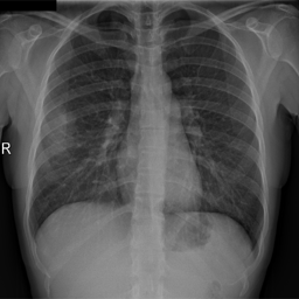

In [19]:
random_image_cov = random.choice(COVID_IMAGE_PATH_LIST)
cov_pic = Image.open(random_image_cov).convert('L')
cov_pic.show()


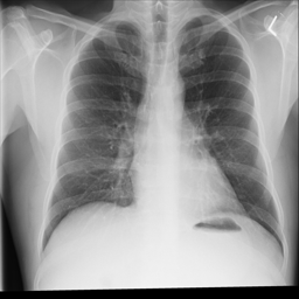

PIL.Image.Image

In [20]:
random_image_ncov = random.choice(NON_COVID_IMAGE_PATH_LIST)
ncov_pic = Image.open(random_image_ncov).convert('L')
ncov_pic.show()
type(ncov_pic)

In [21]:
def image_show(image_list, label):
  fig, subs = plt.subplots(3,3, figsize=(16,12))
  for i, sub in enumerate(subs.flatten()):
    #image_path = os.path.normpath(image[i])
    print(f'Image path is {image_list[i]} and label is {label}')
    img = Image.open(image_list[i])
    img.thumbnail((224,224))
    sub.imshow(img, cmap='gray')
    #sub.axis("off")
    print(f'Size of displayed image is {img.size}')
    sub.set_title(label)

In [22]:
random.seed(3)
ll_d_c =  []
for i in range(9):
  im = random.choice(COVID_IMAGE_PATH_LIST)
  ll_d_c.append(im)
print(ll_d_c, len(ll_d_c))

ll_d_nc = []
for i in range(9):
  im = random.choice(NON_COVID_IMAGE_PATH_LIST)
  ll_d_nc.append(im)

print(ll_d_nc, len(ll_d_nc))


['./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-2121.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-991.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-3292.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1386.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1054.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1091.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-2067.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1727.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1569.png'] 9
['./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-6687.png', './content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-4632.png', './content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-3784.png', './content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-8287.png', './content/dat

Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-2121.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-991.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-3292.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1386.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1054.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1091.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-2067.png and label is COVID
Size of displayed image is (224, 224)


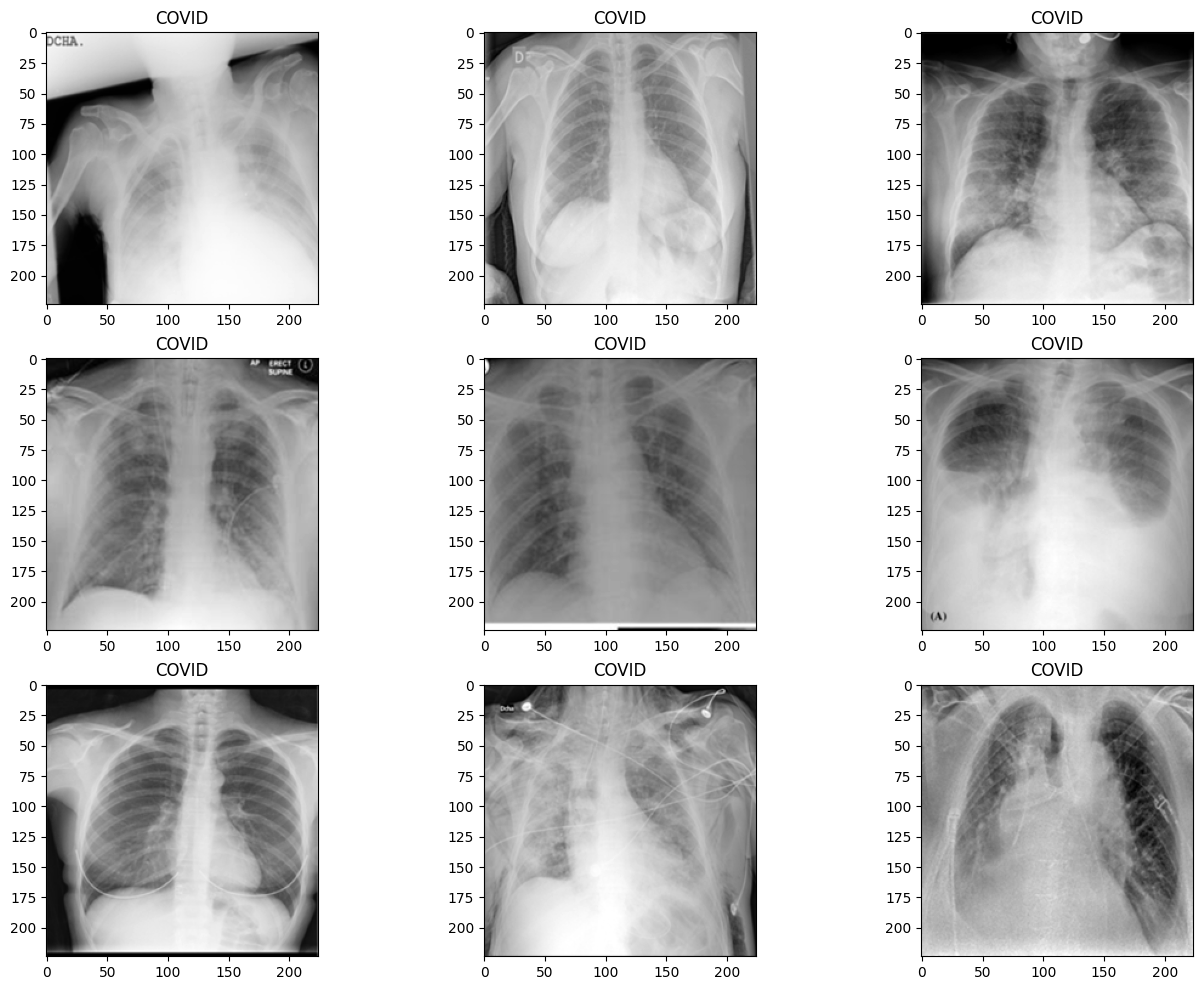

In [23]:
image_show(ll_d_c, 'COVID')

Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-6687.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-4632.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-3784.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-8287.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-7156.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-3783.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-8963.png and label is NON-C

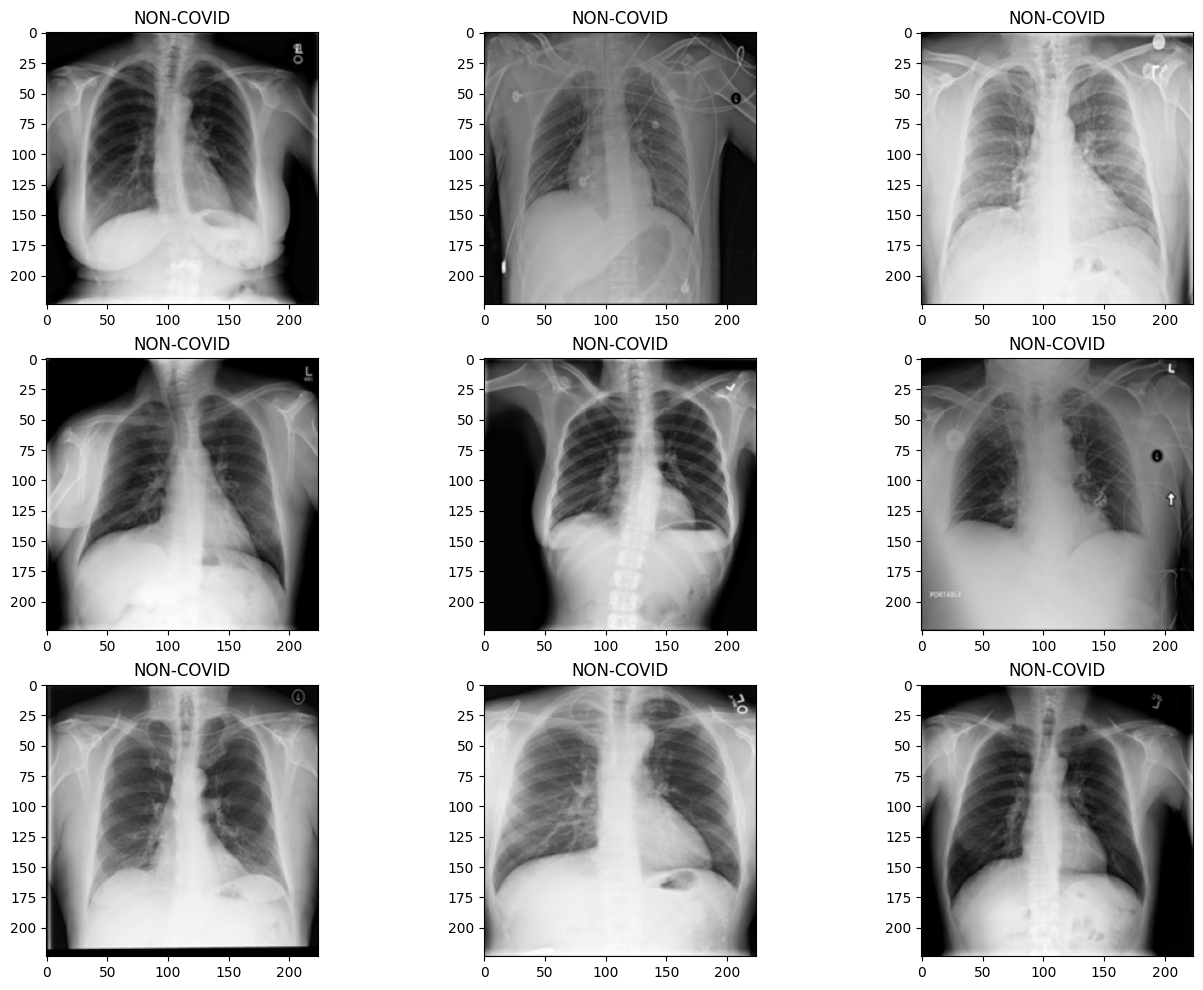

In [24]:
image_show(ll_d_nc, 'NON-COVID')

In [25]:
random_image = random.choice(COVID_IMAGE_PATH_LIST)
random_image_gs = Image.open(random_image).convert('L')
shape= random_image_gs.size
img= np.reshape(random_image_gs, (-1, *shape, 1))
img.shape  

(1, 299, 299, 1)

In [26]:
#def img_resize_save(img_path_list):
#  for i in range(len(img_path_list)):
#    temp_img = Image.open(img_path_list[i])
#    temp_img.thumbnail((224,224))
#    temp_img.save(img_path_list[i])
#  print('All images in supplied list resized to (224,224)')

#Originally I was under impression that all files have to be resized to 224,224 and then saved to disk. This is mentioned as a separate task.
#Hence, the logical deduction

In [27]:
df = pd.DataFrame({'Class': [len(NON_COVID_IMAGE_PATH_LIST), len(COVID_IMAGE_PATH_LIST)]})

In [28]:
total_class = df.Class.sum()
total_class

13808

In [29]:
df['per_distr'] = df['Class'].apply(lambda x: x/total_class)
df.index = ['Non_Covid', 'Covid']

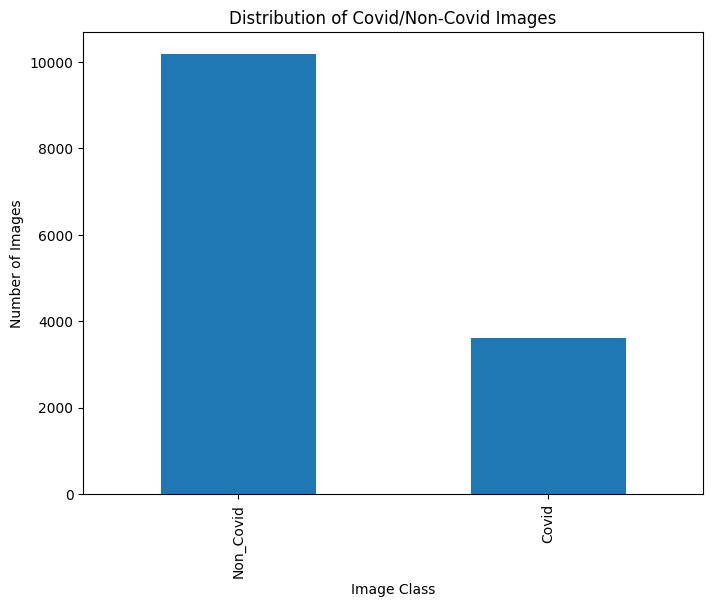

In [30]:
df.Class.plot(kind="bar", figsize=(8,6))
plt.ylabel("Number of Images")
plt.xlabel("Image Class")
plt.title("Distribution of Covid/Non-Covid Images")
plt.show()

In [31]:
list_arr = []
for pic in COVID_IMAGE_PATH_LIST:
  pic_np = np.array(Image.open(pic).convert('L'))
  pic_np = pic_np.reshape(299,299,1)
  list_arr.append(pic_np)


In [32]:
len(list_arr)

3616

In [33]:
covid_arr = np.array(list_arr)

In [34]:
covid_arr.shape

(3616, 299, 299, 1)

In [35]:
np.mean(covid_arr), np.min(covid_arr), np.max(covid_arr), np.std(covid_arr)


(139.52120961679765, 0, 255, 61.90712697550053)

In [36]:
# Flatten the image data into a 1D array
pixel_values = covid_arr.flatten()

pixel_values.shape

(323274016,)

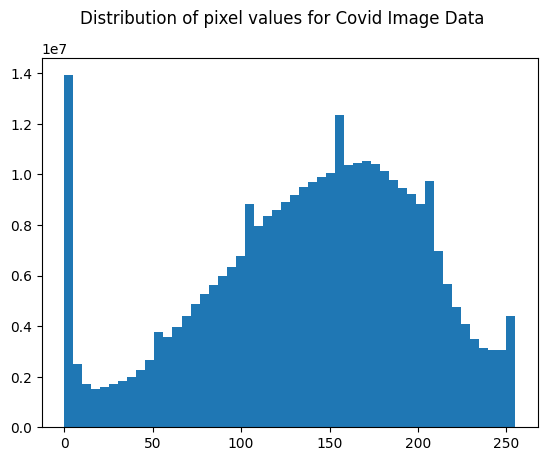

In [37]:
# Plot a histogram of the pixel values
plt.hist(pixel_values, bins=50)
plt.suptitle("Distribution of pixel values for Covid Image Data")
plt.show()

In [38]:
list_arr_nc = []
for pic in NON_COVID_IMAGE_PATH_LIST:
  pic_np_nc = np.array(Image.open(pic).convert('L'))
  pic_np_nc = pic_np_nc.reshape(299,299,1)
  list_arr_nc.append(pic_np_nc)
len(list_arr_nc)

10192

In [39]:
covid_arr_nc = np.array(list_arr_nc)
covid_arr_nc.shape


(10192, 299, 299, 1)

In [40]:
np.mean(covid_arr_nc), np.max(covid_arr_nc), np.mean(covid_arr_nc), np.std(covid_arr_nc)

(129.38979982014257, 255, 129.38979982014257, 66.21686464627422)

In [41]:
# Flatten the image data into a 1D array
pixel_values_nc = covid_arr_nc.flatten()
pixel_values_nc.shape

(911174992,)

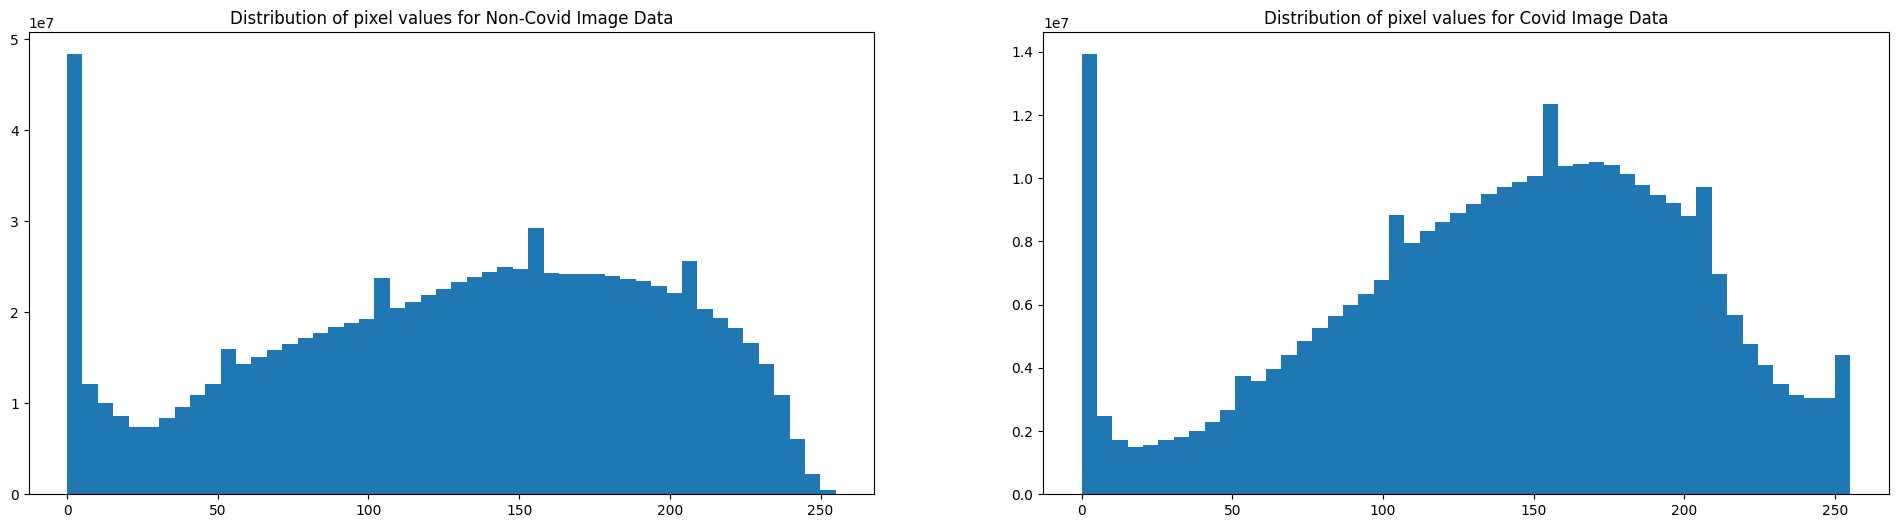

In [42]:
# Plot a histogram of the pixel values
fig, subs = plt.subplots(1,2, figsize=(24,6))
for i, sub in enumerate(subs.flatten()):
  if i==0:
    sub.hist(pixel_values_nc, bins=50)
    sub.set_title("Distribution of pixel values for Non-Covid Image Data")
  else:
    sub.hist(pixel_values, bins=50)
    sub.set_title("Distribution of pixel values for Covid Image Data")




## Observation

It can be seen from above two histograms that pixel intensity for covid data is more peaked(kurtosis is high) than for non-covid images. 

This confirms with fact that X-Ray images for covid infected patients show white patches in chest X-Ray Images.

In [43]:
#Lets do simple check on whether the pixel data that we get from converted .dcm files is same what we get from original png image
image = COVID_IMAGE_PATH_LIST[0]
im1 = Image.open(image).convert('L')
im1= np.array(im1)
img= sitk.GetImageFromArray(im1)
sitk.WriteImage(img,'template.dcm')
    

<class 'numpy.ndarray'>


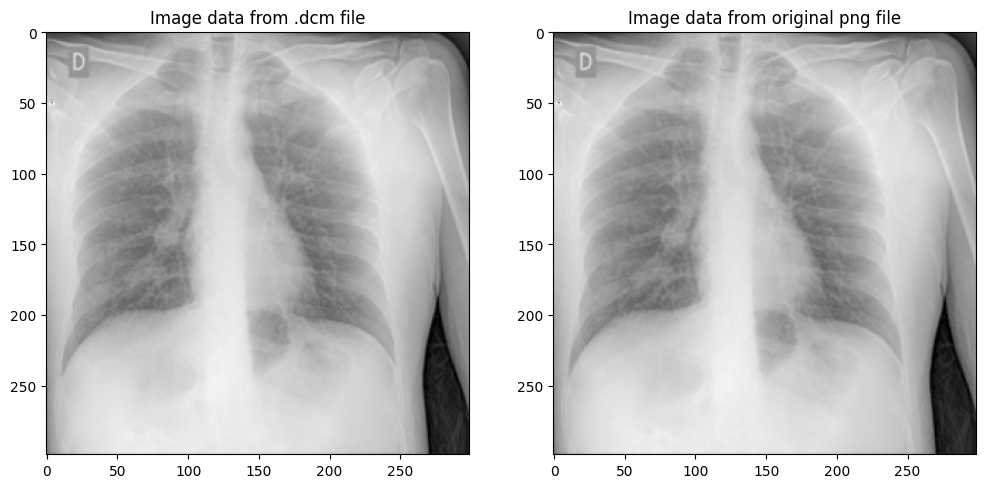

In [44]:
fig, subs = plt.subplots(1,2, figsize=(12,6))
for i, sub in enumerate(subs.flatten()):
  if i==0:
    #ds = pydicom.dcmread('template.dcm')
    # Load the DICOM file
    ds = pydicom.dcmread('template.dcm')
    # Access the image data
    image_d = ds.pixel_array
    print(type(image_d))
    sub.imshow(image_d, cmap='gray')
    sub.set_title("Image data from .dcm file")
  else:
    sub.imshow(im1, cmap='gray')
    sub.set_title("Image data from original png file")

## It does looks like the data from both sources are one and same. 
## STATUS : VERIFIED

## Convert all the PNG Files to DICOM (.dcm) Format

In [45]:
DCM_FILE_PATH = './content/data/DCM/'
COVID_DCM_FILE_PATH = './content/data/DCM/COVID/'
NON_COVID_DCM_FILE_PATH = './content/data/DCM/NON_COVID/'
if os.path.exists(DCM_FILE_PATH):
  print(f"{DCM_FILE_PATH} directory exists.")
  if os.path.exists(COVID_DCM_FILE_PATH):
    print(f'{COVID_DCM_FILE_PATH} directory exists')
  else:
    print(f'Ok... looks like {COVID_DCM_FILE_PATH} does not exists. Let us make one')
    os.mkdir(COVID_DCM_FILE_PATH)
    print(f'{COVID_DCM_FILE_PATH} directory created successfully')
  if os.path.exists(NON_COVID_DCM_FILE_PATH):
    print(f'{NON_COVID_DCM_FILE_PATH} directory exists')
  else:
    print(f'Ok... looks like {NON_COVID_DCM_FILE_PATH} does not exists. Let us make one')
    os.mkdir(NON_COVID_DCM_FILE_PATH)
    print(f'{NON_COVID_DCM_FILE_PATH} directory created successfully')
else:
  print(f'Looks like there is no directory structure below /content/data.. Lets create required directory structures')
  print(f'Creating {DCM_FILE_PATH} directory path first')
  os.mkdir(DCM_FILE_PATH)
  print(f'{DCM_FILE_PATH} directory created successfully')

  print(f'Creating {COVID_DCM_FILE_PATH} directory path')
  os.mkdir(COVID_DCM_FILE_PATH)
  print(f'{COVID_DCM_FILE_PATH} directory created successfully')

  print(f'Creating {NON_COVID_DCM_FILE_PATH} directory path')
  os.mkdir(NON_COVID_DCM_FILE_PATH)
  print(f'{NON_COVID_DCM_FILE_PATH} directory created successfully')



Looks like there is no directory structure below /content/data.. Lets create required directory structures
Creating ./content/data/DCM/ directory path first
./content/data/DCM/ directory created successfully
Creating ./content/data/DCM/COVID/ directory path
./content/data/DCM/COVID/ directory created successfully
Creating ./content/data/DCM/NON_COVID/ directory path
./content/data/DCM/NON_COVID/ directory created successfully


In [46]:

def pngtodcm(image_list, COVID, l_i):
  print(f'COVID variable is set to {COVID}')
  list_im = []
  list_im = l_i

  for png_image in image_list:
    png_im_arr = np.array(Image.open(png_image).convert('L'))
    dcm_im_arr = sitk.GetImageFromArray(png_im_arr)
    if COVID:
      SAVE_PATH = COVID_DCM_FILE_PATH
      list_im = list_im_c
    else:
      SAVE_PATH = NON_COVID_DCM_FILE_PATH
      list_im = list_im_nc
    FILENAME = png_image.split("/")[-1].split(".")[0]
    DCM_FILENAME = SAVE_PATH + FILENAME + '.dcm'
    sitk.WriteImage(dcm_im_arr, DCM_FILENAME)
    print(f'Successfully converted and saved {DCM_FILENAME}')
    list_im.append(DCM_FILENAME)




In [47]:
list_im_c = []
pngtodcm(COVID_IMAGE_PATH_LIST, True, list_im_c)

COVID variable is set to True
Successfully converted and saved ./content/data/DCM/COVID/COVID-215.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-1264.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-2130.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-861.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-3149.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-2966.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-585.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-1351.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-3400.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-330.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-2889.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-842.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-4.dcm
Successfully converted and sa

In [48]:
len(list_im_c)

3616

In [49]:
list_im_nc = []
pngtodcm(NON_COVID_IMAGE_PATH_LIST, False, list_im_nc)

Streaming output truncated to the last 5000 lines.
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-6660.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-6345.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-2968.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-9611.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-3971.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-7791.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-390.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-10042.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-8214.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-1126.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-4484.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-1351.dcm
Successfully 

In [50]:
len(list_im_nc), len(list_im_c)

(10192, 3616)

In [51]:
len(NON_COVID_IMAGE_PATH_LIST), len(COVID_IMAGE_PATH_LIST)

(10192, 3616)

In [52]:
list_im_nc[0], list_im_c[0]

('./content/data/DCM/NON_COVID/Normal-9163.dcm',
 './content/data/DCM/COVID/COVID-215.dcm')

In [53]:
def extract_fnames(file_list):
  temp_ll = []
  for i in file_list:
    fname = i.split("/")[-1].split(".")[0]
    temp_ll.append(fname)
    return sorted(temp_ll)

In [54]:
ll_dc_fname = extract_fnames(list_im_c)
ll_dnc_fname = extract_fnames(list_im_nc)
ll_pc_fname = extract_fnames(COVID_IMAGE_PATH_LIST)
ll_pnc_fname = extract_fnames(NON_COVID_IMAGE_PATH_LIST)



In [55]:
ll_dc_fname == ll_pc_fname

True

In [56]:
ll_dnc_fname == ll_pnc_fname

True

In [57]:
df_nc = pd.DataFrame()

In [58]:
df_nc['filename'] = list_im_nc

In [59]:
df_nc['class'] = 0

In [60]:
df_nc

,filename,class
0,./content/data/DCM/NON_COVID/Normal-9163.dcm,0
1,./content/data/DCM/NON_COVID/Normal-2617.dcm,0
2,./content/data/DCM/NON_COVID/Normal-618.dcm,0
3,./content/data/DCM/NON_COVID/Normal-2518.dcm,0
4,./content/data/DCM/NON_COVID/Normal-8107.dcm,0
...,...,...
10187,./content/data/DCM/NON_COVID/Normal-6162.dcm,0
10188,./content/data/DCM/NON_COVID/Normal-5351.dcm,0
10189,./content/data/DCM/NON_COVID/Normal-9010.dcm,0
10190,./content/data/DCM/NON_COVID/Normal-5527.dcm,0


In [61]:
label_1 = list(np.ones(len(list_im_c), dtype=int))
len(label_1), len(list_im_c)

(3616, 3616)

In [62]:
dict_c = {'filename': list_im_c, 'class': label_1}

In [63]:
df_c = pd.DataFrame(data=dict_c)

In [64]:
df_c

,filename,class
0,./content/data/DCM/COVID/COVID-215.dcm,1
1,./content/data/DCM/COVID/COVID-1264.dcm,1
2,./content/data/DCM/COVID/COVID-2130.dcm,1
3,./content/data/DCM/COVID/COVID-861.dcm,1
4,./content/data/DCM/COVID/COVID-3149.dcm,1
...,...,...
3611,./content/data/DCM/COVID/COVID-774.dcm,1
3612,./content/data/DCM/COVID/COVID-739.dcm,1
3613,./content/data/DCM/COVID/COVID-1787.dcm,1
3614,./content/data/DCM/COVID/COVID-888.dcm,1


In [65]:
df = pd.concat([df_nc, df_c])

In [66]:
df.reset_index(inplace=True)

In [67]:
df.drop(columns=['index'], inplace=True)

In [68]:
df

,filename,class
0,./content/data/DCM/NON_COVID/Normal-9163.dcm,0
1,./content/data/DCM/NON_COVID/Normal-2617.dcm,0
2,./content/data/DCM/NON_COVID/Normal-618.dcm,0
3,./content/data/DCM/NON_COVID/Normal-2518.dcm,0
4,./content/data/DCM/NON_COVID/Normal-8107.dcm,0
...,...,...
13803,./content/data/DCM/COVID/COVID-774.dcm,1
13804,./content/data/DCM/COVID/COVID-739.dcm,1
13805,./content/data/DCM/COVID/COVID-1787.dcm,1
13806,./content/data/DCM/COVID/COVID-888.dcm,1


In [69]:
df['class'].value_counts()

0    10192
1     3616
Name: class, dtype: int64

In [70]:
df.to_csv('./content/data/DCM/dcm_files_list_labels.csv', index=False)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13808 entries, 0 to 13807
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  13808 non-null  object
 1   class     13808 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 215.9+ KB


## Milestone 1.2

In [72]:
df_loaddata = pd.read_csv('./content/data/DCM/dcm_files_list_labels.csv')

In [73]:
df_loaddata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13808 entries, 0 to 13807
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  13808 non-null  object
 1   class     13808 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 215.9+ KB


In [74]:
len(df_loaddata.filename.unique())

13808

In [75]:
df_loaddata['class'].value_counts()

0    10192
1     3616
Name: class, dtype: int64

In [76]:
df_X = df_loaddata.drop(columns=['class'])
df_y = df_loaddata['class']

In [77]:
df_y.head(), df_X.head()

(0    0
 1    0
 2    0
 3    0
 4    0
 Name: class, dtype: int64,
                                        filename
 0  ./content/data/DCM/NON_COVID/Normal-9163.dcm
 1  ./content/data/DCM/NON_COVID/Normal-2617.dcm
 2   ./content/data/DCM/NON_COVID/Normal-618.dcm
 3  ./content/data/DCM/NON_COVID/Normal-2518.dcm
 4  ./content/data/DCM/NON_COVID/Normal-8107.dcm)

In [78]:
train_df, test_df = train_test_split(df_loaddata, test_size=0.2, random_state=42, stratify=df['class'])

len(train_df), len(test_df)

(11046, 2762)

In [79]:
# we need to further reserve 20% data in training for validation
train_df, valid_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['class'])

len(train_df), len(valid_df)

(8836, 2210)

In [80]:
train_df['class'].sum(), valid_df['class'].sum(), test_df['class'].sum()

(2314, 579, 723)

In [81]:
train_df['class'].sum() + valid_df['class'].sum() + test_df['class'].sum()

3616

In [82]:
train_aug_params = dict(
    #rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range = [0.8, 1.2]
)

valid_aug_params = dict(
    #rescale=1./255
    )

test_aug_params = dict(
    #rescale=1./255
)


In [83]:
#Creating augmenters

train_augmenter = ImageDataGenerator(**train_aug_params)
valid_augmenter = ImageDataGenerator(**valid_aug_params)
test_augmenter = ImageDataGenerator(**test_aug_params)

In [84]:
type(train_augmenter), type(valid_augmenter), type(test_augmenter)

(keras.preprocessing.image.ImageDataGenerator,
 keras.preprocessing.image.ImageDataGenerator,
 keras.preprocessing.image.ImageDataGenerator)

In [85]:
# training parameters
BATCH_SIZE = 32
COLOR_MODE = 'grayscale'
TARGET_SIZE = (224, 224)
EPOCHS = 10

train_consts = {
    'batch_size': BATCH_SIZE,
    'color_mode': COLOR_MODE,
    'target_size': TARGET_SIZE,  
}

valid_consts = {
    'batch_size': BATCH_SIZE,
    'color_mode': COLOR_MODE,
    'target_size': TARGET_SIZE, 
    'shuffle': False
}

test_consts = {
    'batch_size': BATCH_SIZE,
    'color_mode': COLOR_MODE,
    'target_size': TARGET_SIZE,  # resize input images
    'shuffle': False
}


In [86]:
class DCMDataFrameIterator(DataFrameIterator):
    def __init__(self, *arg, **kwargs):
        self.white_list_formats = ('dcm')
        super(DCMDataFrameIterator, self).__init__(*arg, **kwargs)
        self.dataframe = kwargs['dataframe']
        self.x = self.dataframe[kwargs['x_col']]
        self.y = self.dataframe[kwargs['y_col']]
        self.color_mode = kwargs['color_mode']
        self.target_size = kwargs['target_size']

    def _get_batches_of_transformed_samples(self, indices_array):
        # get batch of images
        batch_x = np.array([self.read_dcm_as_array(dcm_path, self.target_size, color_mode=self.color_mode)
                            for dcm_path in self.x.iloc[indices_array]])

        batch_y = np.array(self.y.iloc[indices_array].astype(np.uint8))  # astype because y was passed as str

        # transform images
        if self.image_data_generator is not None:
            for i, (x, y) in enumerate(zip(batch_x, batch_y)):
                transform_params = self.image_data_generator.get_random_transform(x.shape)
                batch_x[i] = self.image_data_generator.apply_transform(x, transform_params)
                
                # you can change y here as well, eg: in semantic segmentation you want to transform masks as well 
                # using the same image_data_generator transformations.

        return batch_x, batch_y

    @staticmethod
    def read_dcm_as_array(dcm_path, target_size=(256, 256), color_mode='rgb'):
        image_array = pydicom.dcmread(dcm_path).pixel_array
        image = Image.fromarray(image_array) #converts from array to PIL
        #image = Image.open(image).convert('L')
        image.thumbnail((224,224)) #resize image to 224,224
        #image_array = cv2.resize(image_array, target_size, interpolation=cv2.INTER_NEAREST)  #this returns a 2d array
        image_array = np.expand_dims(image, -1)
        return image_array.astype(np.float32)

In [87]:
train_df['class'] = train_df['class'].astype('str')
valid_df['class'] = valid_df['class'].astype('str')
test_df['class'] = test_df['class'].astype('str')

In [88]:
train_df.info(), valid_df.info(),  test_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8836 entries, 13528 to 8134
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  8836 non-null   object
 1   class     8836 non-null   object
dtypes: object(2)
memory usage: 207.1+ KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2210 entries, 6681 to 12452
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2210 non-null   object
 1   class     2210 non-null   object
dtypes: object(2)
memory usage: 51.8+ KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2762 entries, 1939 to 8436
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2762 non-null   object
 1   class     2762 non-null   object
dtypes: object(2)
memory usage: 64.7+ KB


(None, None, None)

In [89]:
train_generator = DCMDataFrameIterator(dataframe=train_df,
                             x_col='filename',
                             y_col='class',
                             image_data_generator=train_augmenter,
                             **train_consts)

valid_generator = DCMDataFrameIterator(dataframe=valid_df,
                             x_col='filename',
                             y_col='class',
                             image_data_generator=valid_augmenter,
                             **valid_consts)

test_generator = DCMDataFrameIterator(dataframe=test_df,
                             x_col='filename',
                             y_col='class',
                             image_data_generator=test_augmenter,
                             **test_consts)

Found 8836 validated image filenames belonging to 2 classes.
Found 2210 validated image filenames belonging to 2 classes.
Found 2762 validated image filenames belonging to 2 classes.


In [90]:
#train_augmenter.fit(train_generator)

In [91]:
classes = ['NON-COVID', 'COVID']

In [92]:
#Lets fetch some images from generator to ensure it is working good
imgs, labels = next(iter(train_generator))

imgs.shape, labels.shape, type(imgs), type(labels)

((32, 224, 224, 1), (32,), numpy.ndarray, numpy.ndarray)

In [93]:
imgs[0].mean(), imgs[0].max(), imgs[0].min()

(109.09138, 216.0, 0.0)

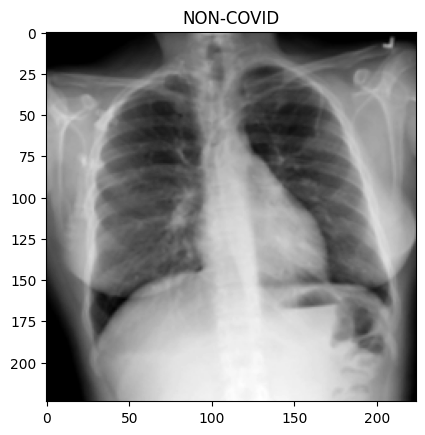

In [94]:
plt.imshow(imgs[0], cmap='gray')
plt.title(classes[labels[0]])
plt.show()

(32, 224, 224, 1) (32,) <class 'numpy.ndarray'> <class 'numpy.ndarray'>


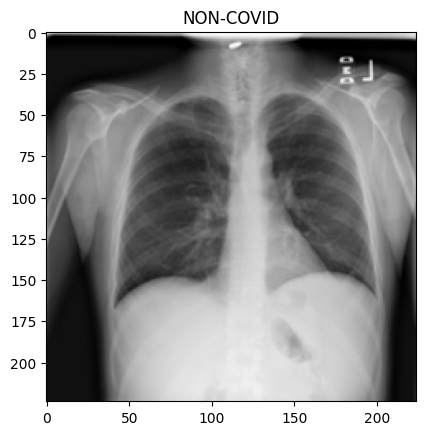

In [95]:
#Lets fetch some images from generator to ensure it is working good
imgs, labels = next(iter(valid_generator))
print(imgs.shape, labels.shape, type(imgs), type(labels))
plt.imshow(imgs[0], cmap='gray')
plt.title(classes[labels[0]])
plt.show()

(32, 224, 224, 1) (32,) <class 'numpy.ndarray'> <class 'numpy.ndarray'>


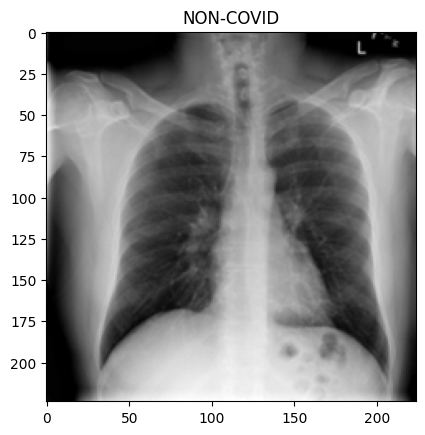

In [96]:
#Lets fetch some images from generator to ensure it is working good
imgs, labels = next(iter(test_generator))
print(imgs.shape, labels.shape, type(imgs), type(labels))
plt.imshow(imgs[0], cmap='gray')
plt.title(classes[labels[0]])
plt.show()

In [97]:
imgs[0].dtype

dtype('float32')

In [98]:
#imgs[0]

In [99]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Add, Flatten, LayerNormalization, Activation, Input
from tensorflow.keras import Sequential
try:
    from einops import rearrange, repeat
    from einops.layers.tensorflow import Rearrange
except:
    print("Einops not installed, Initiating install")
    !pip install einops
    from einops import rearrange, repeat
    from einops.layers.tensorflow import Rearrange
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

Einops not installed, Initiating install
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.4 MB/s eta 0:00:00


In [100]:
basemodel = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=Input(shape=(224,224,3)), pooling='avg')
basemodel.summary()

16705208/16705208 [==============================] - 2s 0us/step
Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 224, 224, 3)  7           ['rescaling[0][0]']              
                                                                                                  
 rescaling_1 (Rescal

In [101]:
class EfficientNetB0_TL(tensorflow.keras.Model):
  def __init__(self):
    super().__init__()

    self.conv_layer = Conv2D(3, (3,3), padding='same')

    self.basemodel = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=Input(shape=(224,224,3)))
    for layer in self.basemodel.layers:
      layer.trainable=False
    self.classifier = Sequential([
        Flatten(),
        Dense(512, use_bias=False),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.1),
        Dense(128, use_bias=False),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.1),
        Dense(2)
    ])

  def call(self,x):
    #for layer in self.basemodel.layers:
     # layer.trainable=False
    x = self.conv_layer(x)
    #x = preprocess_input(x)
    x = self.basemodel(x)
    x = self.classifier(x)
    return x

In [102]:
model = EfficientNetB0_TL()

In [103]:
X_input = Input(shape=(224,224,1,))
out = EfficientNetB0_TL()(X_input)
temp_model = Model(inputs=X_input, outputs=out)
temp_model.summary(expand_nested=True)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 1)]     0         
                                                                 
 efficient_net_b0_tl_1 (Effi  (None, 2)                36230595  
 cientNetB0_TL)                                                  
|¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯|
| conv2d_1 (Conv2D)         multiple                  30        |
|                                                               |
| efficientnetb0 (Functional)  (None, 7, 7, 1280)     4049571   |
||¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯||
|| input_4 (InputLayer)    [(None, 224, 224, 3)]     0         ||
||                                                             ||
|| rescaling_4 (Rescaling)  (None, 224, 224, 3)      0         ||
||                                                           

In [104]:
from tensorflow.keras.optimizers.schedules import LearningRateSchedule
from tensorflow import data, train, math, reduce_sum, cast, equal, argmax, \
float32, GradientTape, TensorSpec, function, int64

In [105]:
opt = Adam(learning_rate=0.0001)
loss_fn = tensorflow.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [106]:
train_acc_metric = tensorflow.keras.metrics.SparseCategoricalAccuracy()
val_acc_metric = tensorflow.keras.metrics.SparseCategoricalAccuracy()
test_acc_metric = tensorflow.keras.metrics.SparseCategoricalAccuracy()


In [107]:
from sklearn.metrics import confusion_matrix

In [108]:
if os.path.exists('./content/data/ckpt'):
    print(f'Weight Checkpoint directory already exists')
    !ls -ld ./content/data/ckpt
else:
    print(f'Weight Checkpooint directory doesnt exists.. Creating it now..')
    os.mkdir('./content/data/ckpt')
    print(f'Weight Checkpoint directory successfully created')
    !ls -ld ./content/data/ckpt

    
if os.path.exists('./content/data/saved_model'):
    print(f'Protobuf Checkpoint directory already exists')
    !ls -ld ./content/data/saved_model
else:
    print(f'Protobuf Checkpoint directory doesnt exists.. Creating it now..')
    os.mkdir('./content/data/saved_model')
    print(f'Weight Checkpoint directory successfully created')
    !ls -ld ./content/data/saved_model

Weight Checkpooint directory doesnt exists.. Creating it now..
Weight Checkpoint directory successfully created
drwxr-xr-x 2 root root 4096 Apr 21 01:59 ./content/data/ckpt
Protobuf Checkpoint directory doesnt exists.. Creating it now..
Weight Checkpoint directory successfully created
drwxr-xr-x 2 root root 4096 Apr 21 01:59 ./content/data/saved_model


In [109]:
class Model_Train():
  def __init__(self, model, optimizer, loss_fn, epochs, batch_size, train_gen, valid_gen, test_gen, train_acc_metric, val_acc_metric, test_acc_metric):
    super().__init__()

    self.model = model
    self.optimizer = optimizer
    self.loss_fn = loss_fn
    self.epochs = epochs
    self.batch_size = batch_size
    self.train_generator = train_gen
    self.valid_generator = valid_gen
    self.test_generator = test_gen
    self.steps_train = len(train_gen)
    self.steps_valid = len(valid_gen)
    self.steps_test = len(test_gen)
    self.train_acc_metric = train_acc_metric
    self.val_acc_metric = val_acc_metric
    self.test_acc_metric = test_acc_metric
    self.train_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': []}
    self.valid_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'ckpt_name': []}


   

  @tensorflow.function
  def train_step(self, train_data, train_label):
    with tensorflow.GradientTape() as tape:
      output = self.model(train_data, training=True)
      loss_value = self.loss_fn(train_label, output)
    grads = tape.gradient(loss_value, self.model.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.model.trainable_weights))
    self.train_acc_metric.update_state(train_label, output)
    return output, loss_value

  @tensorflow.function
  def test_step(self, validation_data, validation_label):
    val_output = self.model(validation_data, training=False)
    loss_value = self.loss_fn(validation_label, val_output)
    self.val_acc_metric.update_state(validation_label, val_output)
    return val_output, loss_value

  def getloss_accuracy(self, gen, batch_size, steps_per_epoch, df, train=False, valid=False):
    loss_epoch = 0
    n=0
    for step, (x_batch, y_batch) in enumerate(gen):
      if train:
        output, loss_value = self.train_step(x_batch, y_batch)
        ###new code below
        
        pred_labls = list(np.argmax(output.numpy(), axis=1))
        temp_df = pd.DataFrame({'orig_label': list(y_batch), 'pred_label': pred_labls})
        df = pd.concat([df, temp_df])
            

        ## newcode above
        
      else:
        output, loss_value = self.test_step(x_batch, y_batch)
        pred_labls = list(np.argmax(output.numpy(), axis=1))
        temp_df = pd.DataFrame({'orig_label': list(y_batch), 'pred_label': pred_labls})
        df = pd.concat([df, temp_df])
            
      loss_epoch += loss_value*x_batch.shape[0]
      #n = n+1
      #print("Training step ", n )
      if step >= (steps_per_epoch-1):
        if train:
          avg_epoch_loss = (loss_epoch/(len(train_df))).numpy()
          accuracy = self.train_acc_metric.result().numpy()
          self.train_acc_metric.reset_states()
          gen.on_epoch_end()
        else:
          if valid:
            avg_epoch_loss = (loss_epoch/(len(valid_df))).numpy()
            accuracy = self.val_acc_metric.result().numpy()
            self.val_acc_metric.reset_states()
          else:
            avg_epoch_loss = (loss_epoch/(len(test_df))).numpy()
            accuracy = self.val_acc_metric.result().numpy()
            self.val_acc_metric.reset_states()


        return df, avg_epoch_loss, accuracy

  def train_validate_loop(self):
    for epoch in range(self.epochs):
      start_time = time.time()
      histdf_train = pd.DataFrame({'orig_label': [], 'pred_label': []})
      histdf_val   = pd.DataFrame({'orig_label': [], 'pred_label': []})  

      df_train_cm, avg_epoch_train_loss, train_accuracy = self.getloss_accuracy(self.train_generator, self.batch_size, self.steps_train, histdf_train, train=True)
      df_val_cm, avg_epoch_val_loss, val_accuracy = self.getloss_accuracy(self.valid_generator, self.batch_size, self.steps_valid, histdf_val, train=False, valid=True)

    
      f1, precision, recall             = self.calc_rec_prec_f1(df_train_cm, train=True)
      f1_val, precision_val, recall_val = self.calc_rec_prec_f1(df_val_cm, train=False)


      print(f'Epoch : {epoch}, Train Loss: {avg_epoch_train_loss}, Train Accuracy: {train_accuracy}, Validation Loss: {avg_epoch_val_loss}, Validation Accuracy: {val_accuracy}')
      
      self.train_history['loss'].append(avg_epoch_train_loss)
      self.train_history['accuracy'].append(train_accuracy)
      self.train_history['f1'].append(f1)
      self.train_history['precision'].append(precision)
      self.train_history['recall'].append(recall)

      self.valid_history['loss'].append(avg_epoch_val_loss)
      self.valid_history['accuracy'].append(val_accuracy)
      self.valid_history['f1'].append(f1_val)
      self.valid_history['precision'].append(precision_val)
      self.valid_history['recall'].append(recall_val)

      ###New Code for early stopping#####
      la = self.valid_history['accuracy']
      if (len(la) > 4):
        if (((la[-1] <= la[-2]) and (la[-2] <= la[-3])) and ((la[-3] <= la[-4]) and (la[-4] <= la[-5]))):
          print("Validation accuracy has not improved over last 4 epochs, hence invoking early stopping and exiting training process")
          if len(self.valid_history['ckpt_name']) > 0:
            print('Loading Best weights..')
            self.model.load_weights(self.valid_history['ckpt_name'][-1])
            break
          else:
            print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")
            break
                        
      if ((la[-1] > 0.9) and (len(la) > 1)):
        if(la[-1] > max(la[0:-1])):
          self.save_checkpoint(la[-1])
      elif ((la[-1] > 0.9) and (len(la) == 1)):
        self.save_checkpoint(la[-1])





      #####New Cod for early stopping


    
      print(f'Time taken: {np.round((time.time() - start_time), 4)}')
    print(f'Training completed successfully. Loading best checkpoint weights ...')
    if len(self.valid_history['ckpt_name']) > 0:
      self.model.load_weights(self.valid_history['ckpt_name'][-1])
      print(f'Best checkpoint weights loaded : {self.valid_history["ckpt_name"][-1]}')
    else:
      print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")

      #draw graph depicting train and validation losses and accuracy + recall, f1
    return self.train_history, self.valid_history

  def save_checkpoint(self, acc):
    ckpt_name = './content/data/ckpt/' + 'ckpt' + '_' + str(acc) + '_acc.pt'
    #pb_name = './content/data/saved_model/' + 'ckpt' + '_' + str(acc) + '_acc'
    self.model.save_weights(ckpt_name)
    self.valid_history['ckpt_name'].append(ckpt_name)
    print(f'Saved Checkpoint : {ckpt_name}')
    #self.model.save(pb_name)
    #print(f'Saved model in protobuf format : {pb_name}')


  def get_test_accuracy(self):
    df = pd.DataFrame({'orig_label': [], 'pred_label': []})
    df_test, avg_test_loss, test_accuracy = self.getloss_accuracy(self.test_generator, self.batch_size, self.steps_test, df)
    return df_test, avg_test_loss, test_accuracy

  def calc_rec_prec_f1(self, df, train):
    print_string = "Training Confusion Matrix" if train else "Validation Confusion Matrix"
    print(print_string, "\n", confusion_matrix(df['orig_label'], df['pred_label']))
    tn, fp, fn, tp = confusion_matrix(df['orig_label'], df['pred_label']).ravel()
    precision = tp/(tp+fp)
    recall = tp/(tp+fn)
    f1 = 2*precision*recall/(precision+recall)
    return f1, precision, recall

  def predict_single(self,dcm_path, target_size=(224,224)):
    image_array = pydicom.dcmread(dcm_path).pixel_array
    image = Image.fromarray(image_array) #converts from array to PIL
    #image.thumbnail((224,224)) #resize image to 224,224
    image = image.resize((224,224))
    image_array = np.expand_dims(image, 0)
    image_array = image_array.astype(np.float32) # * (1.0/255.0)
    image_array = np.expand_dims(image_array, -1)
    output = self.model(image_array, training=False)
    pred_label = np.argmax(output.numpy())
    print(f'Predicted label for image supplied is : {classes[pred_label]}')
    return classes[pred_label]
    
  def pred_image_show(self,image_list):
    fig, subs = plt.subplots(3,3, figsize=(14,12))
    for i, sub in enumerate(subs.flatten()):
      print(f'Image path is {image_list[i][0]} and Original label is {classes[int(image_list[i][1])]}')
      pred_class = self.predict_single(image_list[i][0])
      image_array = pydicom.dcmread(image_list[i][0]).pixel_array
      sub.imshow(image_array, cmap='gray')
      sub.set_title(f'{pred_class}(Pred) : {classes[int(image_list[i][1])]}(Orig)')
            
  def plot_metrics(self):
    list = ['accuracy', 'loss', 'f1', 'recall', 'precision']
    for metrics in list:
      x = [i for i in range(len(self.train_history[metrics]))]
      y1 = self.train_history[metrics]
      y2 = self.valid_history[metrics]
      fig, ax = plt.subplots()
      ax.plot(x, y1, label="train_"+metrics)
      ax.plot(x, y2, label="valid_"+metrics)
      plt.suptitle(f'Plot showing {metrics} for Different Epoch Runs')
      ax.legend()
      plt.show()
## Save weights
## if current accuracy > 90 and current accuracy > max(list_accuracy) then create checkpoint and save weights. Also do a protobuf saved model
## store the saved checkpoint name in a list. This will make sure than checkpoints are stored in asecnding order.
## at the end of training , take the last element in checkpoint list and load and restore it. test accuracy should be checked using this chkpoint.
    

In [110]:
EPOCHS = 20
train_object = Model_Train(model, opt, loss_fn, EPOCHS, BATCH_SIZE, train_generator, valid_generator, test_generator,
             train_acc_metric, val_acc_metric, test_acc_metric
             )

In [111]:
train_object.__dict__

{'model': <__main__.EfficientNetB0_TL at 0x7fa8ec76ab20>,
 'optimizer': <keras.optimizers.adam.Adam at 0x7fa86cba1b20>,
 'loss_fn': <keras.losses.SparseCategoricalCrossentropy at 0x7fa86cba1af0>,
 'epochs': 20,
 'batch_size': 32,
 'train_generator': <__main__.DCMDataFrameIterator at 0x7fa9945998e0>,
 'valid_generator': <__main__.DCMDataFrameIterator at 0x7fa994599970>,
 'test_generator': <__main__.DCMDataFrameIterator at 0x7fa99453d670>,
 'steps_train': 277,
 'steps_valid': 70,
 'steps_test': 87,
 'train_acc_metric': <keras.metrics.accuracy_metrics.SparseCategoricalAccuracy at 0x7fa86cb9e190>,
 'val_acc_metric': <keras.metrics.accuracy_metrics.SparseCategoricalAccuracy at 0x7fa86cb9e4f0>,
 'test_acc_metric': <keras.metrics.accuracy_metrics.SparseCategoricalAccuracy at 0x7fa86cb9ee80>,
 'train_history': {'loss': [],
  'accuracy': [],
  'f1': [],
  'precision': [],
  'recall': []},
 'valid_history': {'loss': [],
  'accuracy': [],
  'f1': [],
  'precision': [],
  'recall': [],
  'ckpt_nam

In [112]:
train_dict, val_dict = train_object.train_validate_loop()

Training Confusion Matrix 
 [[5948  582]
 [ 503 1803]]
Validation Confusion Matrix 
 [[1601   30]
 [ 105  474]]
Epoch : 0, Train Loss: 0.29671069979667664, Train Accuracy: 0.8772068619728088, Validation Loss: 0.15860813856124878, Validation Accuracy: 0.9389140009880066
Saved Checkpoint : ./content/data/ckpt/ckpt_0.938914_acc.pt
Time taken: 157.6887
Training Confusion Matrix 
 [[6265  256]
 [ 413 1902]]
Validation Confusion Matrix 
 [[1597   34]
 [  73  506]]
Epoch : 1, Train Loss: 0.1909344643354416, Train Accuracy: 0.9242870211601257, Validation Loss: 0.13376030325889587, Validation Accuracy: 0.9515836834907532
Saved Checkpoint : ./content/data/ckpt/ckpt_0.9515837_acc.pt
Time taken: 117.9718
Training Confusion Matrix 
 [[6296  222]
 [ 351 1967]]
Validation Confusion Matrix 
 [[1579   52]
 [  48  531]]
Epoch : 2, Train Loss: 0.1703621745109558, Train Accuracy: 0.9351516366004944, Validation Loss: 0.12241814285516739, Validation Accuracy: 0.9547511339187622
Saved Checkpoint : ./content/

In [113]:
df, loss, accuracy = train_object.get_test_accuracy() #from df returned by function you can check which image has lables incorrectly predicted

In [114]:
accuracy

0.98044896

In [115]:
confusion_matrix(df['orig_label'], df['pred_label'])

array([[2018,   21],
       [  33,  690]])

In [116]:
643/(643+80)

0.8893499308437067

In [117]:
train_object.predict_single(test_df.iloc[-2,0])

Predicted label for image supplied is : COVID


'COVID'

In [118]:
train_object.model.save_weights('./content/data/ckpt/model_best_weights')

In [119]:
with zipfile.ZipFile('./XRAY_resnet50_model_best_weights.zip', 'w') as myzip:
    myzip.write('./content/data/ckpt/checkpoint')
    myzip.write('./content/data/ckpt/model_best_weights.data-00000-of-00001')
    #myzip.write('./content/data/ckpt/model_best_weights.data-00001-of-00002')
    myzip.write('./content/data/ckpt/model_best_weights.index')

In [120]:
random_9_test = random.sample(list(test_df.values), 9)
random_9_test, len(random_9_test)

([array(['./content/data/DCM/NON_COVID/Normal-3121.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-4722.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-3031.dcm', '0'], dtype=object),
  array(['./content/data/DCM/COVID/COVID-2782.dcm', '1'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-7228.dcm', '0'], dtype=object),
  array(['./content/data/DCM/COVID/COVID-2295.dcm', '1'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-6019.dcm', '0'], dtype=object),
  array(['./content/data/DCM/COVID/COVID-2870.dcm', '1'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-3387.dcm', '0'], dtype=object)],
 9)

In [121]:
random_9_test[0][0], random_9_test[0][1]

('./content/data/DCM/NON_COVID/Normal-3121.dcm', '0')

Image path is ./content/data/DCM/NON_COVID/Normal-3121.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-4722.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-3031.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/COVID/COVID-2782.dcm and Original label is COVID
Predicted label for image supplied is : COVID
Image path is ./content/data/DCM/NON_COVID/Normal-7228.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/COVID/COVID-2295.dcm and Original label is COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-6019.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/CO

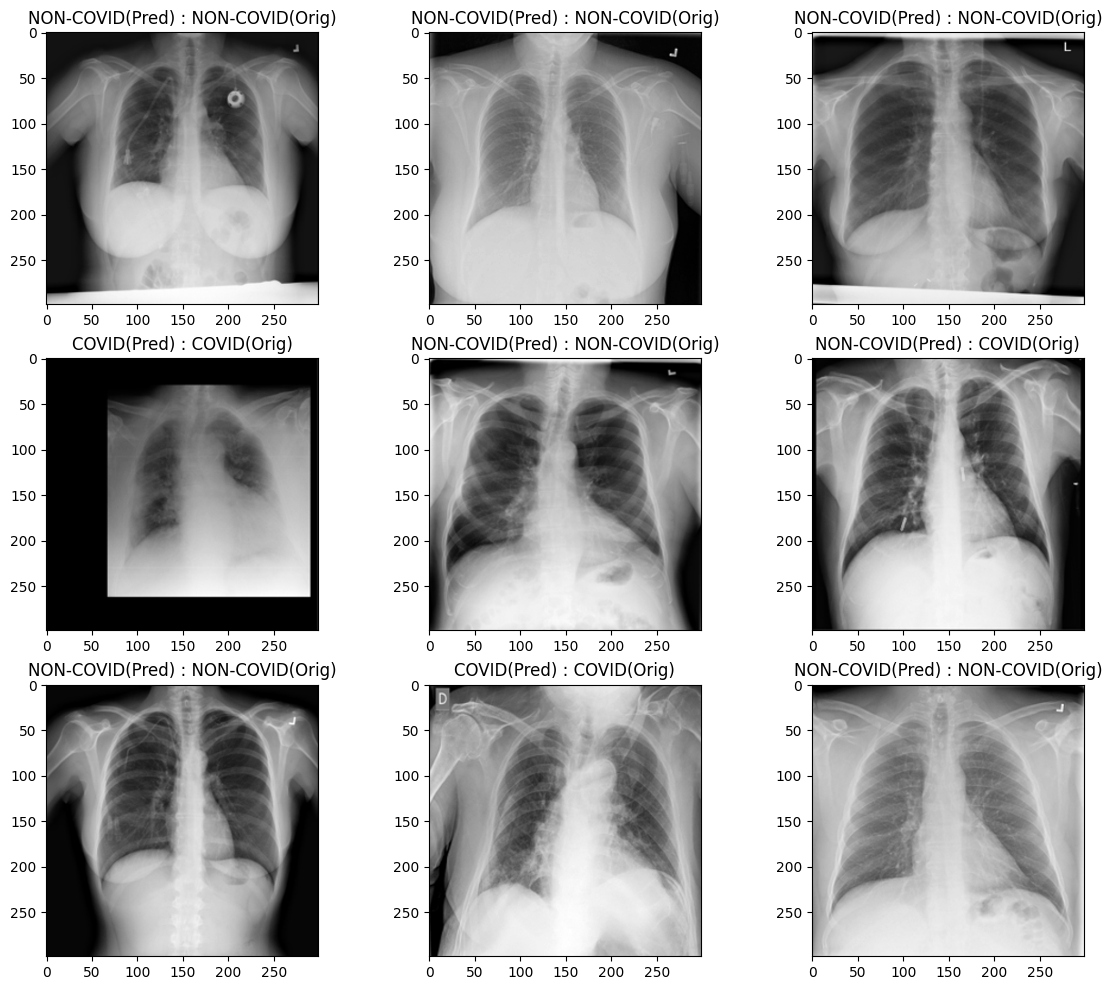

In [122]:
train_object.pred_image_show(random_9_test)

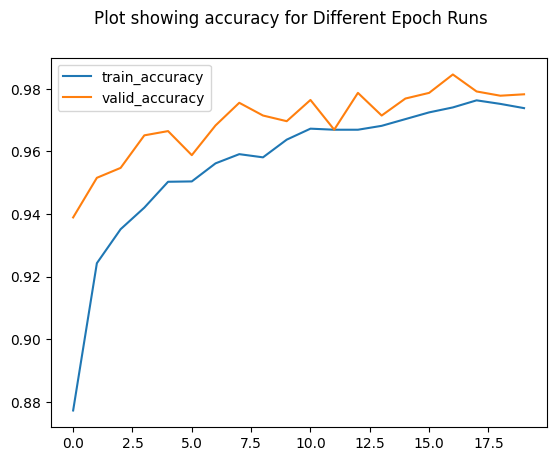

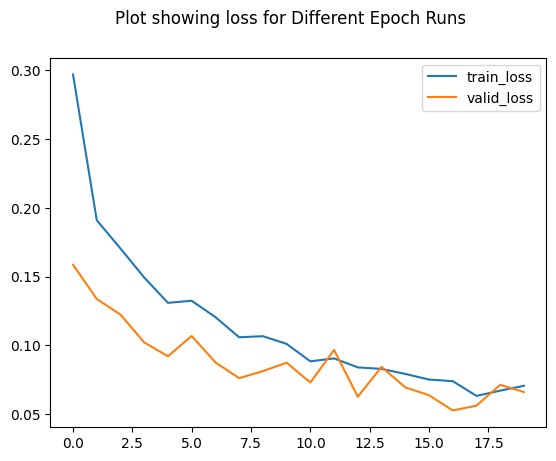

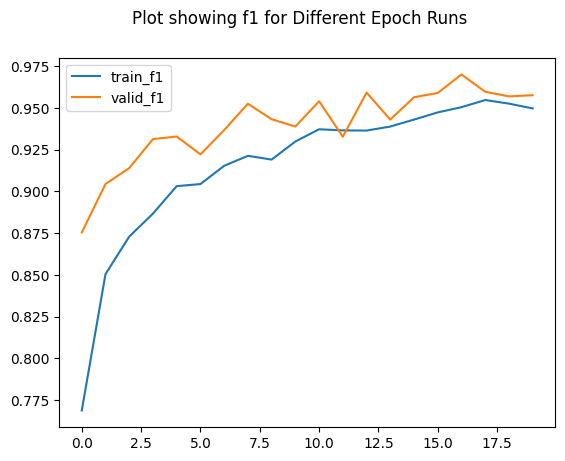

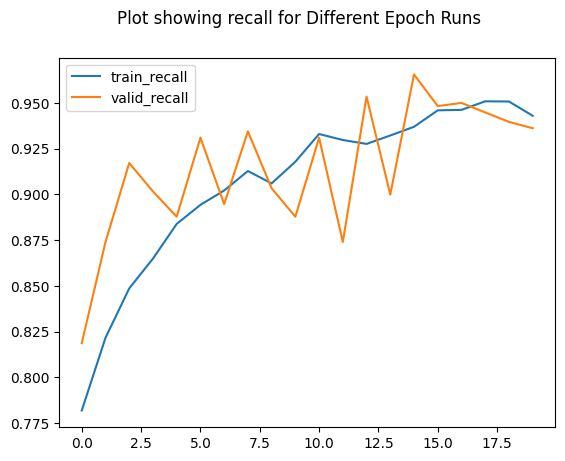

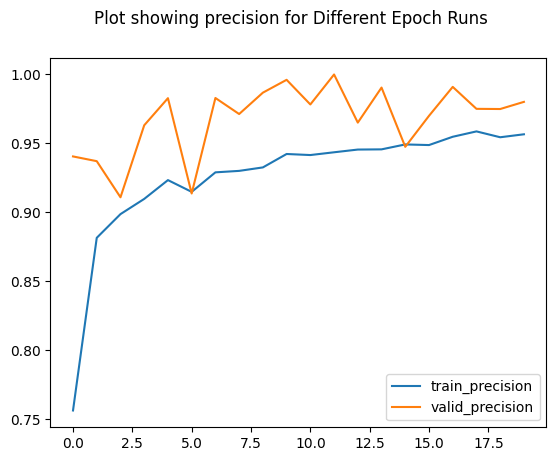

In [123]:
train_object.plot_metrics()

In [124]:
!cp ./*model_best_weights.zip ./gdrive/MyDrive/Manning_Projects/